<a href="https://colab.research.google.com/github/babiologa/Bioestat-stica/blob/main/tarefa04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 ## Bioestatística - tarefa 04.

 Dante Gomes Soares de Morais - 16883610

 Barbara Aimy Baldin - 16856147

 Marina de Oliveira Cappato - 16898499

Base de dados: Iris - UCI Machine Learning Repository


## Base de dados utilizada

A base de dados utilizada é a Iris, disponibilizada pelo UCI Machine Learning Repository.

A base contém 150 observações, correspondentes a plantas de três espécies do gênero Iris, com 50 observações de cada espécie. São apresentadas quatro variáveis quantitativas relacionadas às características morfológicas das plantas:

- comprimento da sépala (`sepal_length`);
- largura da sépala (`sepal_width`);
- comprimento da pétala (`petal_length`);
- largura da pétala (`petal_width`).

As medidas das estruturas vegetais são expressas em centímetros.

Para esta atividade, foi selecionada a variável comprimento da pétala (`petal_length`), por ser uma variável quantitativa contínua e representar uma característica morfológica que pode ser analisada por meio de medidas de posição e dispersão.

Fonte dos dados: UCI Machine Learning Repository.

Fisher, R. (1936). Iris [Dataset]. UCI Machine Learning Repository.
https://doi.org/10.24432/C56C76

## Revisão teórica

Na estatística, os quartis são medidas que ajudam a entender como os dados estão distribuídos. Eles dividem os dados, quando colocados em ordem, em quatro partes.

O primeiro quartil (Q1) corresponde a 25% dos dados. Isso significa que aproximadamente 25% das observações possuem valores menores ou iguais a Q1. O segundo quartil (Q2) corresponde a 50% dos dados e é a mediana, ou seja, o valor que divide o conjunto de dados em duas partes iguais. Já o terceiro quartil (Q3) corresponde a 75% dos dados.

A diferença entre o terceiro e o primeiro quartil é chamada de amplitude interquartílica (AIQ):

\[
AIQ = Q3 - Q1
\]

Essa medida mostra a variação existente entre os 50% centrais dos dados.

O boxplot é um gráfico usado para representar a distribuição dos dados de forma visual. A caixa do gráfico vai de Q1 até Q3, enquanto a linha dentro da caixa representa a mediana (Q2). Os limites do gráfico ajudam a visualizar a dispersão dos dados e a identificar possíveis valores muito diferentes dos demais.

Para verificar a presença de observações atípicas, pode-se usar o critério de 1,5 vezes a amplitude interquartílica. Primeiro, são calculados os limites inferior e superior:

\[
LI = Q1 - 1,5 \times AIQ
\]

\[
LS = Q3 + 1,5 \times AIQ
\]

Os valores menores que o limite inferior ou maiores que o limite superior são considerados atípicos por esse critério.

É importante lembrar que um valor atípico não significa necessariamente que exista um erro nos dados. Ele pode representar uma variação real que merece ser analisada dentro do contexto do estudo.

**Referência:**

MORETTIN, Pedro A.; SINGER, Julio M. *Estatística e ciência de dados*. 1. ed. Rio de Janeiro: LTC, 2023.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [26]:
df = pd.read_excel("tarefa04.xlsx")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
print("Número de linhas e colunas", df.shape)

print("\nColunas:")
print(df.columns.tolist())

print("\nInformações da base:")
df.info()

Número de linhas e colunas (150, 5)

Colunas:
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

Informações da base:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [6]:
df.head(10)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


In [7]:
print(df.isnull().sum)

<bound method DataFrame.sum of      sepal_length  sepal_width  petal_length  petal_width  species
0           False        False         False        False    False
1           False        False         False        False    False
2           False        False         False        False    False
3           False        False         False        False    False
4           False        False         False        False    False
..            ...          ...           ...          ...      ...
145         False        False         False        False    False
146         False        False         False        False    False
147         False        False         False        False    False
148         False        False         False        False    False
149         False        False         False        False    False

[150 rows x 5 columns]>


In [8]:
df["species"].value_counts()

,count
species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


In [10]:

variavel = df["petal_length"]
variavel.head()

,petal_length
0,1.4
1,1.4
2,1.3
3,1.5
4,1.4


In [19]:
del print # Delete the shadowed 'print' variable

Q1 = variavel.quantile(0.25)
Q2 = variavel.quantile(0.50)
Q3 = variavel.quantile(0.75)
print(f"Primeiro quartil (Q1): {Q1:.2f} cm")
print(f"Segundo quartil (Q2 - mediana): {Q2:.2f} cm")
print(f"Terceiro quartil (Q3): {Q3:.2f} cm")

Primeiro quartil (Q1): 1.60 cm
Segundo quartil (Q2 - mediana): 4.35 cm
Terceiro quartil (Q3): 5.10 cm


In [20]:
AIQ = Q3 - Q1
print(f"Amplitude interqualítica (AIQ): {AIQ:.2f} cm")

Amplitude interqualítica (AIQ): 3.50 cm


### Interpretação dos quartis

O primeiro quartil indica que aproximadamente 25% das plantas apresentam comprimento da pétala de até 1,60 cm.

O segundo quartil, ou mediana, corresponde a 4,35 cm. Portanto, metade das observações apresenta comprimento de pétala inferior ou igual a 4,35 cm, enquanto a outra metade apresenta valores superiores ou iguais a esse valor.

O terceiro quartil corresponde a 5,10 cm, indicando que aproximadamente 75% das observações apresentam comprimento de pétala de até 5,10 cm.

A amplitude interquartílica foi de 3,50 cm, indicando que os 50% centrais dos comprimentos de pétala estão distribuídos em um intervalo de 3,50 cm.

In [21]:
limite_inferior = Q1 - 1.5 * AIQ
limite_superior = Q3 + 1.5 * AIQ
print(f"Limite inferior: {limite_inferior:.2f} cm")
print(f"Limite superior: {limite_superior:.2f} cm")

Limite inferior: -3.65 cm
Limite superior: 10.35 cm


In [23]:
outliers = df[
    (df["petal_length"] < limite_inferior) |
    (df["petal_length"] > limite_superior)
]

print("Número de observações atípicas", len(outliers))
outliers


Número de observações atípicas 0


,sepal_length,sepal_width,petal_length,petal_width,species


### **Como determinamos se há observações atípicas em uma base de dados?**

Para determinar se existem observações atípicas, calcula-se inicialmente a amplitude interquartílica, dada pela diferença entre o terceiro e o primeiro quartis:

\[
AIQ = Q3 - Q1
\]

Em seguida, são calculados os limites inferior e superior:

\[
LI = Q1 - 1,5(AIQ)
\]

\[
LS = Q3 + 1,5(AIQ)
\]

Uma observação é considerada atípica pelo critério do boxplot quando apresenta valor menor que o limite inferior ou maior que o limite superior.

Na variável comprimento da pétala da base Iris, os limites encontrados foram de -3,65 cm e 10,35 cm. Como nenhum dos 150 valores está fora desse intervalo, não foram identificadas observações atípicas segundo esse critério.

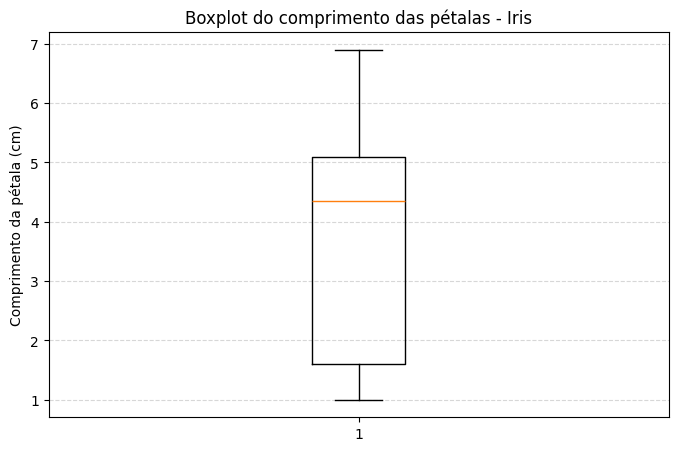

In [24]:
plt.figure(figsize=(8, 5))
plt.boxplot(
    variavel,
    vert=True,
    patch_artist=False
)

plt.ylabel("Comprimento da pétala (cm)")
plt.title("Boxplot do comprimento das pétalas - Iris")
plt.grid(axis="y", linestyle= "--", alpha=0.5)

plt.show()

O boxplot mostra a distribuição do comprimento das pétalas das 150 plantas analisadas.

A linha central da caixa representa a mediana, correspondente a 4,35 cm. Os limites da caixa correspondem ao primeiro quartil (1,60 cm) e ao terceiro quartil (5,10 cm), de modo que a caixa representa os 50% centrais das observações.

A amplitude da caixa corresponde à amplitude interquartílica de 3,50 cm.

Não são observados pontos além dos limites considerados para valores atípicos. Portanto, para o conjunto total de plantas, não foram identificadas observações atípicas de acordo com o critério de 1,5 vezes a amplitude interquartílica.

##Referências

FISHER, R. A. *Iris*. UCI Machine Learning Repository, 1936.
Disponível em: https://archive.ics.uci.edu/dataset/53/iris.
DOI: https://doi.org/10.24432/C56C76. Acesso em: 18 ago. 2026.

MORETTIN, Pedro A.; SINGER, Julio M. *Estatística e ciência de dados*. 1. ed. Rio de Janeiro: LTC, 2023.